# Autoresearch Experiment Analysis

Analysis of autonomous hyperparameter tuning results from `results.tsv`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the TSV (tab-separated, 5 columns: commit, val_bpb, memory_gb, status, description)
df = pd.read_csv("FG_SFT_results.tsv", sep="\t")
df["accuracy"] = pd.to_numeric(df["accuracy"], errors="coerce")
df["status"] = df["status"].str.strip().str.upper()

print(f"Total experiments: {len(df)}")
print(f"Columns: {list(df.columns)}")
df.head(10)

Total experiments: 20
Columns: ['commit', 'accuracy', 'status', 'description']


,commit,accuracy,status,description
0,20d724e,0.8658,KEEP,baseline
1,eaec5d5,0.8699,KEEP,Increase LoRA rank to 16 and alpha to 32
2,9281e34,0.8835,KEEP,Add attn_vec_einsum to LoRA modules
3,ad5e4dd,0.8762,DISCARD,Use Muon optimizer
4,e68be89,0.8814,DISCARD,Increase LoRA rank to 32 and alpha to 64
5,5359cd3,0.0000,DISCARD,Increase batch size to 16
6,d04b20b,0.8876,KEEP,Increase learning rate to 2e-4
7,04947f2,0.8751,DISCARD,Increase learning rate to 3e-4
8,5d22d6f,0.8887,KEEP,Change random seed to 42
9,9f7275f,0.0000,DISCARD,Add dropout 0.05 to LoRA


In [2]:
counts = df["status"].value_counts()
print("Experiment outcomes:")
print(counts.to_string())

n_keep = counts.get("KEEP", 0)
n_discard = counts.get("DISCARD", 0)
n_crash = counts.get("CRASH", 0)
n_decided = n_keep + n_discard
if n_decided > 0:
    print(f"\nKeep rate: {n_keep}/{n_decided} = {n_keep / n_decided:.1%}")

Experiment outcomes:
status
DISCARD    13
KEEP        7

Keep rate: 7/20 = 35.0%


In [3]:
# Show all KEPT experiments (the improvements that stuck)
kept = df[df["status"] == "KEEP"].copy()
print(f"KEPT experiments ({len(kept)} total):\n")
for i, row in kept.iterrows():
    accuracy = row["accuracy"]
    desc = row["description"]
    print(f"  #{i:3d}  accuracy={accuracy:.6f}  {desc}")

KEPT experiments (7 total):

  #  0  accuracy=0.865800  baseline
  #  1  accuracy=0.869900  Increase LoRA rank to 16 and alpha to 32
  #  2  accuracy=0.883500  Add attn_vec_einsum to LoRA modules
  #  6  accuracy=0.887600  Increase learning rate to 2e-4
  #  8  accuracy=0.888700  Change random seed to 42
  # 14  accuracy=0.889700  Change learning rate to 2.5e-4
  # 18  accuracy=0.890700  Change BATCH_SIZE to 4


## Accuracy Over Time

Track how the best (kept) accuracy evolves as experiments progress. The running maximum shows the "frontier" -- the best result achieved so far.

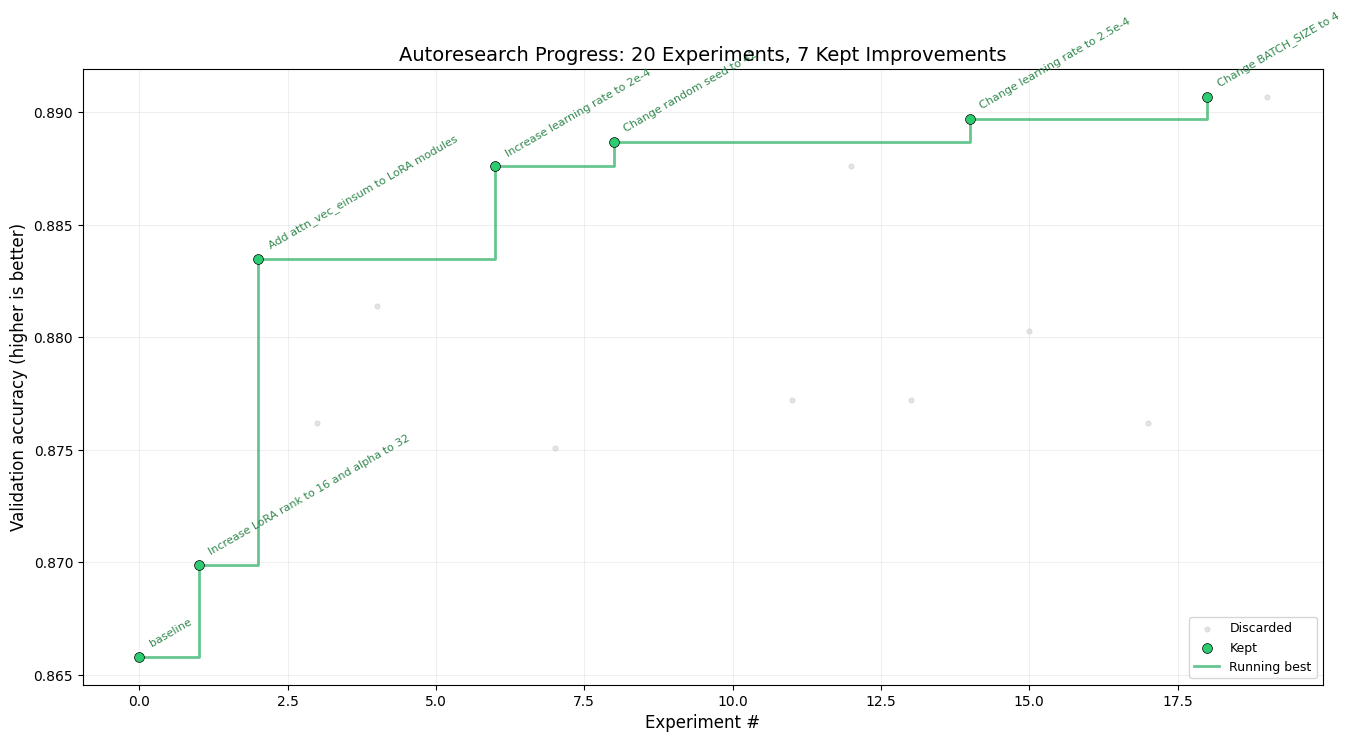

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 8))

# Filter out crashes for plotting
valid = df[df["status"] != "CRASH"].copy()
valid = valid.reset_index(drop=True)

baseline_accuracy = valid.loc[0, "accuracy"]

# Only plot points at or above baseline (the interesting region)
above = valid[valid["accuracy"] >= baseline_accuracy - 0.0005]

# Plot discarded as faint background dots
disc = above[above["status"] == "DISCARD"]
ax.scatter(disc.index, disc["accuracy"],
           c="#cccccc", s=12, alpha=0.5, zorder=2, label="Discarded")

# Plot kept experiments as prominent green dots
kept_v = above[above["status"] == "KEEP"]
ax.scatter(kept_v.index, kept_v["accuracy"],
           c="#2ecc71", s=50, zorder=4, label="Kept", edgecolors="black", linewidths=0.5)

# Running maximum step line
kept_mask = valid["status"] == "KEEP"
kept_idx = valid.index[kept_mask]
kept_accuracy = valid.loc[kept_mask, "accuracy"]
running_max = kept_accuracy.cummax() # Changed to cummax()
ax.step(kept_idx, running_max, where="post", color="#27ae60",
        linewidth=2, alpha=0.7, zorder=3, label="Running best")

# Label each kept experiment with its description
for idx, accuracy in zip(kept_idx, kept_accuracy):
    desc = str(valid.loc[idx, "description"]).strip()
    if len(desc) > 45:
        desc = desc[:42] + "..."

    ax.annotate(desc, (idx, accuracy),
                textcoords="offset points",
                xytext=(6, 6), fontsize=8.0,
                color="#1a7a3a", alpha=0.9,
                rotation=30, ha="left", va="bottom")
    
# Fixed fallback variable from baseline_bpb to baseline_accuracy
best = running_max.iloc[-1] if len(running_max) > 0 else baseline_accuracy
n_total = len(df)
n_kept = len(df[df["status"] == "KEEP"])

ax.set_xlabel("Experiment #", fontsize=12)
ax.set_ylabel("Validation accuracy (higher is better)", fontsize=12) # Updated label
ax.set_title(f"Autoresearch Progress: {n_total} Experiments, {n_kept} Kept Improvements", fontsize=14)
ax.legend(loc="lower right", fontsize=9) # Moved to lower right so the rising line doesn't collide with it
ax.grid(True, alpha=0.2)

# Y-axis: from just below baseline to just above best
margin = (best - baseline_accuracy) * 0.15
# Added absolute value fallback just in case best == baseline